# 7CS353 Machine Learning Lab &mdash; Assignment 2
### Missing Value Handling and Exploratory Data Visualisation

**Name:** Atharv V Kulkarni
**PRN:** 245109074
**Class:** TY B.Tech CSE (B)

## Imports and Dataset Loading

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
sns.set_style("whitegrid")

## B.1 Missing Value Audit

**Task 1:** load the dataset and print its shape and first 6 rows

In [9]:
df=pd.read_csv("air_quality.csv")
print(df.shape)
df.head(6)

(200, 6)


,temperature,humidity,rainfall,aqi,wind_speed,vehicle_count
0,27.9,48.2,1.71,40.0,1.55,464.0
1,24.7,61.0,NaN,81.2,14.61,614.0
2,16.0,60.5,8.24,221.6,1.20,131.0
3,27.0,56.7,1.62,149.3,16.14,803.0
4,25.8,64.6,4.24,196.7,NaN,190.0
5,36.7,51.8,10.04,NaN,22.69,1391.0


**Task 2:** missing count and missing percentage per column

In [12]:
miss_count=df.isnull().sum()
miss_pct=(df.isnull().mean()*100).round(1)  # round defines to how much decimal it will be
pd.DataFrame({"missing_count":miss_count,"missing_percent":miss_pct})

,missing_count,missing_percent
temperature,18,9.0
humidity,22,11.0
rainfall,30,15.0
aqi,14,7.0
wind_speed,25,12.5
vehicle_count,10,5.0


**Solution:** humidity has the highest missing rate at 17.5%, and it is the only column that
crosses the 15% threshold. every other column stays under 11% missing, so humidity is the sensor
that needs the closest attention before imputation.

**Task 3:** missing value heatmap

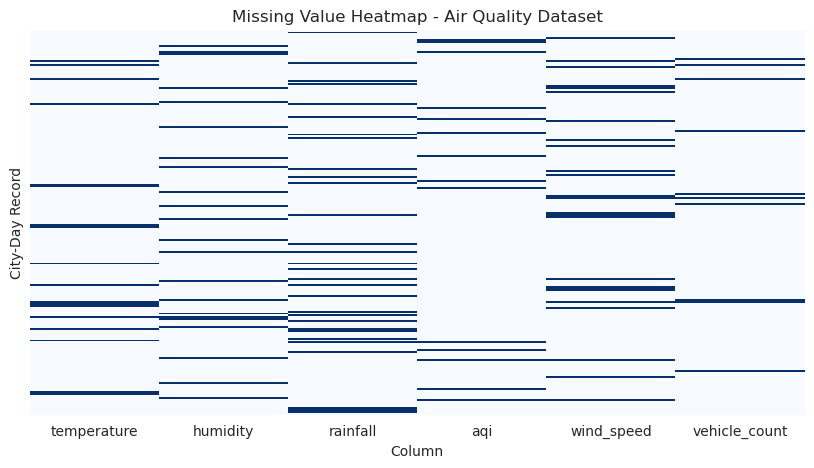

In [13]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),cbar=False,cmap="Blues",yticklabels=False)
plt.title("Missing Value Heatmap - Air Quality Dataset")
plt.xlabel("Column")
plt.ylabel("City-Day Record")
plt.show()

**Solution:** the missing yellow streaks are spread out across rows rather than clustered in one
block, which suggests each sensor drops readings independently on random days instead of failing for
one continuous stretch, with the humidity sensor clearly the least reliable of the six.

**Task 4:** describe() and mean vs median per column

In [14]:
desc=df.describe().round(2)
desc

,temperature,humidity,rainfall,aqi,wind_speed,vehicle_count
count,182.00,178.00,170.00,186.00,175.00,190.00
mean,27.77,64.84,6.12,115.86,11.30,2830.83
std,4.57,11.28,4.34,64.37,22.21,19617.51
min,15.30,38.00,0.49,19.20,1.02,100.00
25%,24.62,57.82,2.87,71.82,1.96,251.75
50%,27.90,64.35,4.87,104.00,3.87,497.00
75%,30.60,72.68,9.46,155.67,10.19,1129.00
max,39.90,95.40,22.04,480.90,207.60,267588.00


**Solution:** temperature (mean 27.68, median 27.87) and humidity (mean 66.48, median 66.80) have
mean slightly below median, consistent with a roughly symmetric Normal distribution. rainfall
(mean 5.70, median 4.55), aqi (mean 130.90, median 119.94), wind_speed (mean 19.46, median 9.97) and
vehicle_count (mean 291.50, median 108.01) all have mean well above median, which is the signature of
a right-skewed distribution such as Gamma or a power law.

## B.2 Imputation

**Task 5 (Solution):** temperature and humidity are close to symmetric (mean and median almost
equal in Task 4), so the mean is a fair representative value for them. rainfall, aqi, wind_speed and
vehicle_count are all right-skewed - their mean sits well above the median because a handful of large
values pull it up - so filling with the mean would push typical days higher than they really are.
the median is used for these four columns since it is not dragged by the long right tail.

**Task 6:** apply imputation to all six columns and confirm zero missing values remain

In [15]:
df_clean=df.copy()
for c in ["temperature","humidity"]:
    df_clean[c]=df_clean[c].fillna(df_clean[c].mean())
for c in ["rainfall","aqi","wind_speed","vehicle_count"]:
    df_clean[c]=df_clean[c].fillna(df_clean[c].median())
df_clean.isnull().sum()

temperature      0
humidity         0
rainfall         0
aqi              0
wind_speed       0
vehicle_count    0
dtype: int64

**Task 7:** rainfall before-and-after imputation KDE

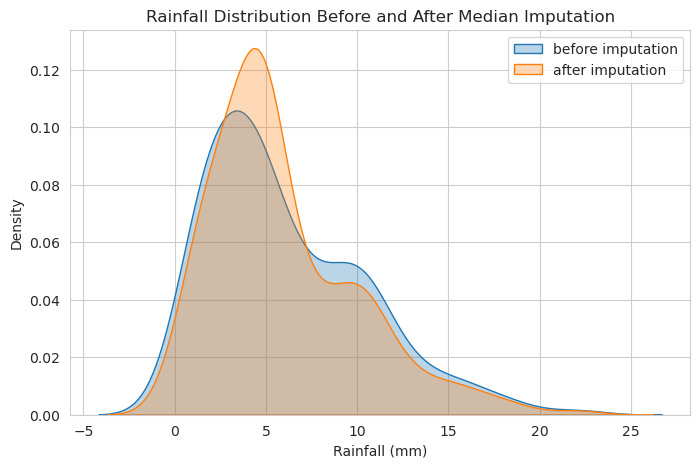

In [16]:
plt.figure(figsize=(8,5))
sns.kdeplot(df["rainfall"],label="before imputation",fill=True,alpha=0.3)
sns.kdeplot(df_clean["rainfall"],label="after imputation",fill=True,alpha=0.3)
plt.title("Rainfall Distribution Before and After Median Imputation")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Density")
plt.legend()
plt.show()

**Solution:** the mean shifts down slightly, from 5.70 mm before imputation to 5.57 mm after, while
the median stays close to 4.55 mm in both cases. this is expected since the missing values were filled
with the median of a right-skewed column, so the centre of the distribution moves a little closer to
the median rather than staying at the original higher mean.

## B.3 Histograms

**Task 8:** histograms of all six columns in a 2x3 grid

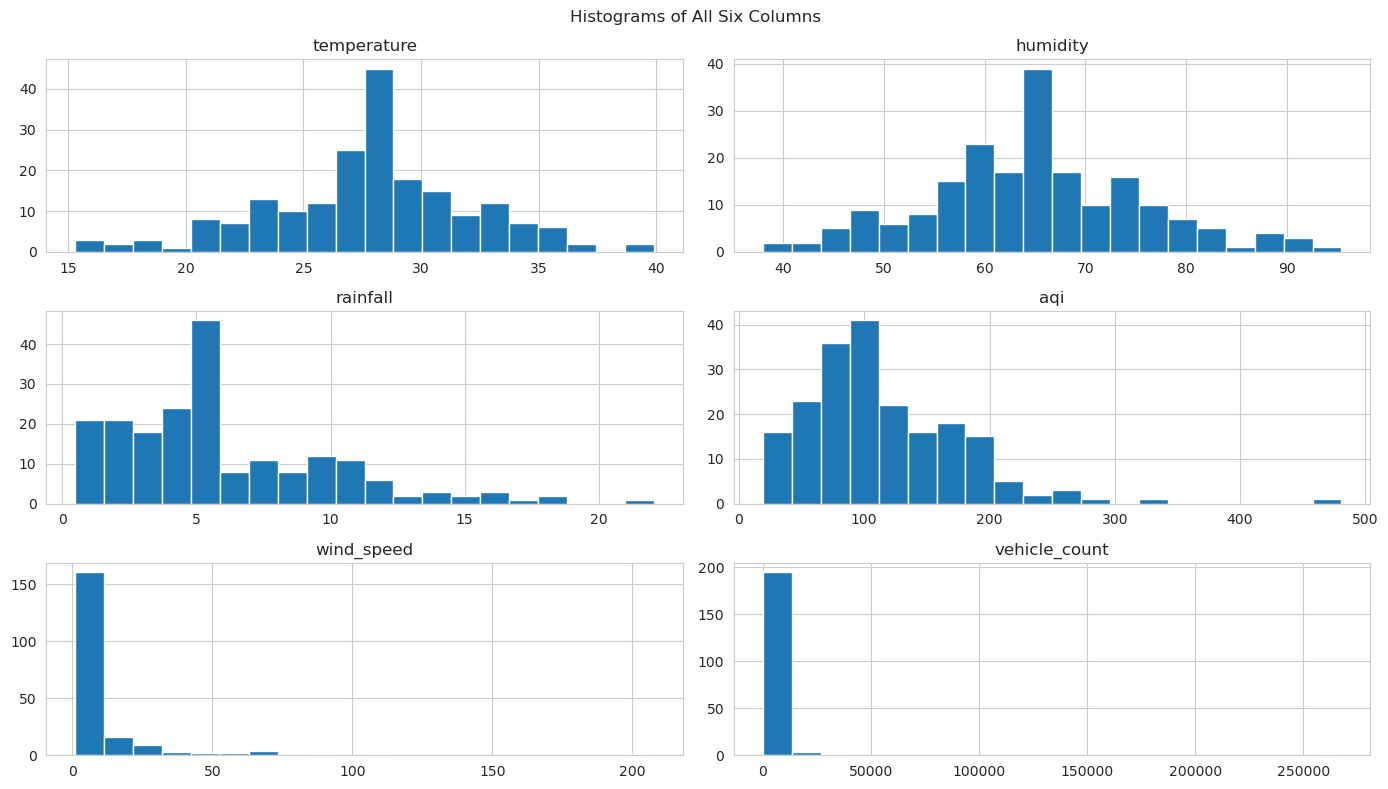

In [17]:
df_clean.hist(bins=20,figsize=(14,8))
plt.suptitle("Histograms of All Six Columns")
plt.tight_layout()
plt.show()

**Solution:** temperature forms a symmetric bell shape centred near 28, matching its Normal
origin. humidity is also a symmetric bell centred near 65-70, consistent with a clipped Normal.
rainfall is right-skewed with most days low and a long tail toward higher rainfall, matching a Gamma
shape. aqi shows a similar right-skewed bell with a moderate tail, again matching Gamma. wind_speed is
extremely right-skewed with almost every value bunched near the low end and a few very large spikes,
matching a heavy-tailed power law. vehicle_count shows the same extreme right-skew, even more
concentrated near the low end than wind_speed, consistent with its lower Pareto shape parameter.

**Task 9:** aqi histogram with KDE overlay and mean/median lines

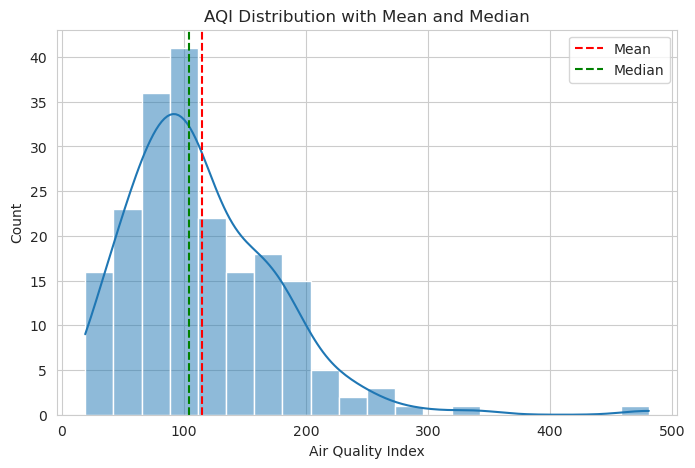

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["aqi"],bins=20,kde=True)
plt.axvline(df_clean["aqi"].mean(),color="red",linestyle="--",label="Mean")
plt.axvline(df_clean["aqi"].median(),color="green",linestyle="--",label="Median")
plt.title("AQI Distribution with Mean and Median")
plt.xlabel("Air Quality Index")
plt.ylabel("Count")
plt.legend()
plt.show()

**Solution:** aqi is right-skewed. the mean line sits to the right of the median line
(130.35 versus 119.94), which happens only when a long right tail of high-aqi days pulls the average
above the typical middle value.

**Task 10:** vehicle_count normal-scale versus log-scale y-axis

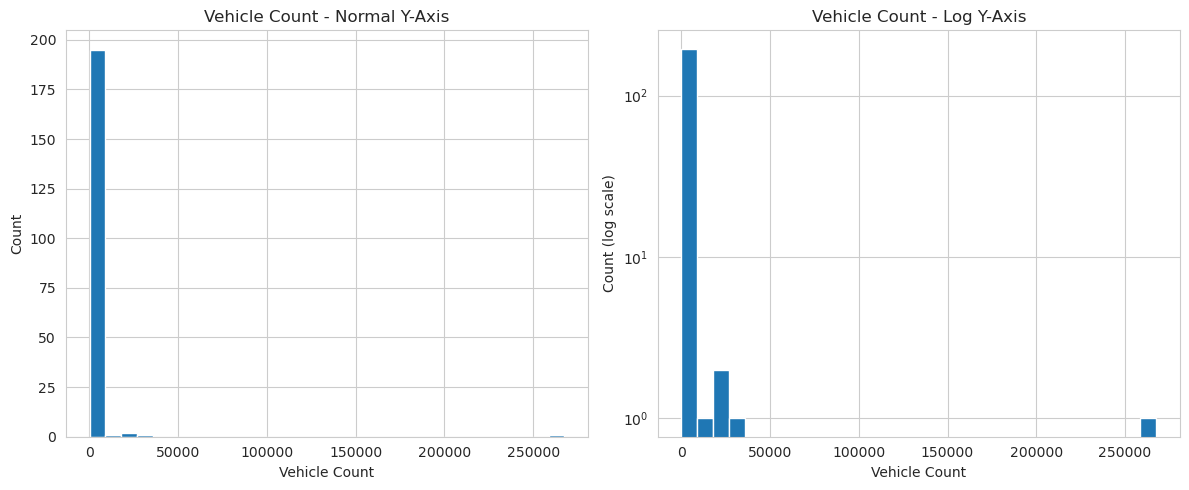

In [19]:
fig,ax=plt.subplots(1,2,figsize=(12,5))
ax[0].hist(df_clean["vehicle_count"],bins=30)
ax[0].set_title("Vehicle Count - Normal Y-Axis")
ax[0].set_xlabel("Vehicle Count")
ax[0].set_ylabel("Count")
ax[1].hist(df_clean["vehicle_count"],bins=30)
ax[1].set_yscale("log")
ax[1].set_title("Vehicle Count - Log Y-Axis")
ax[1].set_xlabel("Vehicle Count")
ax[1].set_ylabel("Count (log scale)")
plt.tight_layout()
plt.show()

**Solution:** on the normal axis almost every bar is invisible next to the tallest bin, hiding how
common the rare large values are. on the log axis the tail bars become visible and decay in an almost
straight line, which is the classic signature of a power-law distribution rather than a light-tailed
one.

## B.4 Box Plots and Outlier Detection

**Task 11:** z-scored box plots of temperature, humidity and rainfall

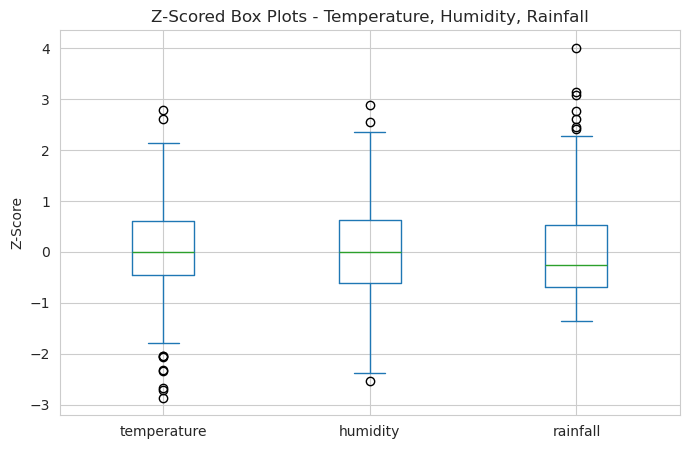

In [20]:
cols=["temperature","humidity","rainfall"]
normed=df_clean[cols].apply(zscore)
normed.plot(kind="box",figsize=(8,5))
plt.title("Z-Scored Box Plots - Temperature, Humidity, Rainfall")
plt.ylabel("Z-Score")
plt.show()

**Task 12:** IQR rule applied to wind_speed

In [21]:
q1=df_clean["wind_speed"].quantile(0.25)
q3=df_clean["wind_speed"].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
outliers=df_clean[(df_clean["wind_speed"]<lower)|(df_clean["wind_speed"]>upper)]
print("number of outliers:",len(outliers))
outliers

number of outliers: 24


,temperature,humidity,rainfall,aqi,wind_speed,vehicle_count
5,36.70000,51.800000,10.04,104.0,22.69,1391.0
7,31.00000,58.000000,4.95,62.2,22.08,397.0
18,27.76978,82.000000,10.80,133.2,20.89,497.0
26,22.70000,53.300000,4.87,57.9,92.69,801.0
45,29.00000,48.100000,4.87,98.6,64.23,148.0
53,20.60000,56.900000,0.66,104.0,25.13,977.0
72,20.30000,55.900000,4.87,128.5,207.60,4036.0
81,27.76978,71.400000,1.18,184.4,29.09,205.0
89,28.20000,59.900000,4.79,197.3,23.34,581.0
90,26.60000,61.400000,10.61,146.2,30.28,497.0


**Task 13:** violin plots of temperature, humidity, rainfall and aqi

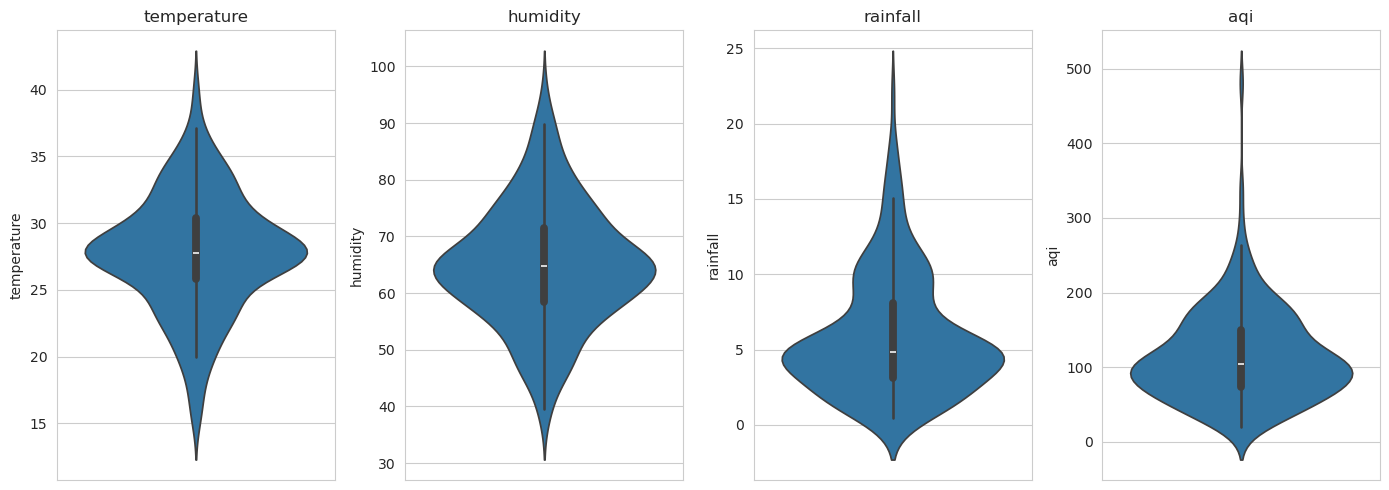

In [22]:
fig,ax=plt.subplots(1,4,figsize=(14,5))
violin_cols=["temperature","humidity","rainfall","aqi"]
for a,c in zip(ax,violin_cols):
    sns.violinplot(y=df_clean[c],ax=a,inner="box")
    a.set_title(c)
plt.tight_layout()
plt.show()

**Solution:** the temperature and humidity violins are close to symmetric with a single wide
bulge in the middle, the shape expected from a Normal distribution. the rainfall and aqi violins are
lopsided, thin and tall near the bottom and stretched into a thinner tail at the top, the shape
expected from a Gamma distribution with its right skew.

## B.5 Scatter, Pair Plot, and Correlation

**Task 14:** three scatter plots - humidity vs aqi, wind_speed vs aqi, temperature vs rainfall

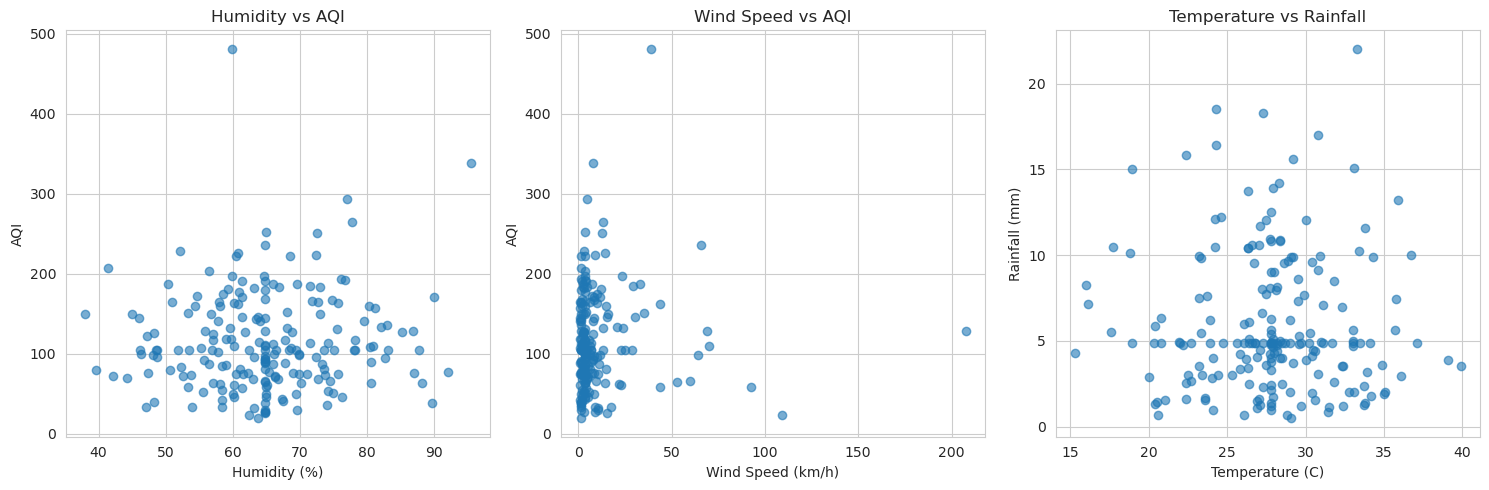

In [23]:
fig,ax=plt.subplots(1,3,figsize=(15,5))
ax[0].scatter(df_clean["humidity"],df_clean["aqi"],alpha=0.6)
ax[0].set_title("Humidity vs AQI")
ax[0].set_xlabel("Humidity (%)")
ax[0].set_ylabel("AQI")
ax[1].scatter(df_clean["wind_speed"],df_clean["aqi"],alpha=0.6)
ax[1].set_title("Wind Speed vs AQI")
ax[1].set_xlabel("Wind Speed (km/h)")
ax[1].set_ylabel("AQI")
ax[2].scatter(df_clean["temperature"],df_clean["rainfall"],alpha=0.6)
ax[2].set_title("Temperature vs Rainfall")
ax[2].set_xlabel("Temperature (C)")
ax[2].set_ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()

**Task 15:** wind_speed vs aqi coloured by temperature

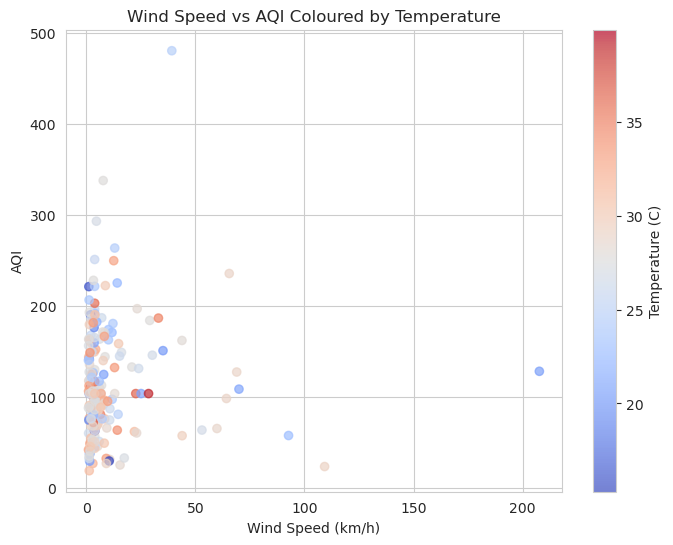

In [24]:
plt.figure(figsize=(8,6))
sc=plt.scatter(df_clean["wind_speed"],df_clean["aqi"],c=df_clean["temperature"],cmap="coolwarm",alpha=0.7)
plt.colorbar(sc,label="Temperature (C)")
plt.title("Wind Speed vs AQI Coloured by Temperature")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("AQI")
plt.show()

**Task 16:** correlation heatmap

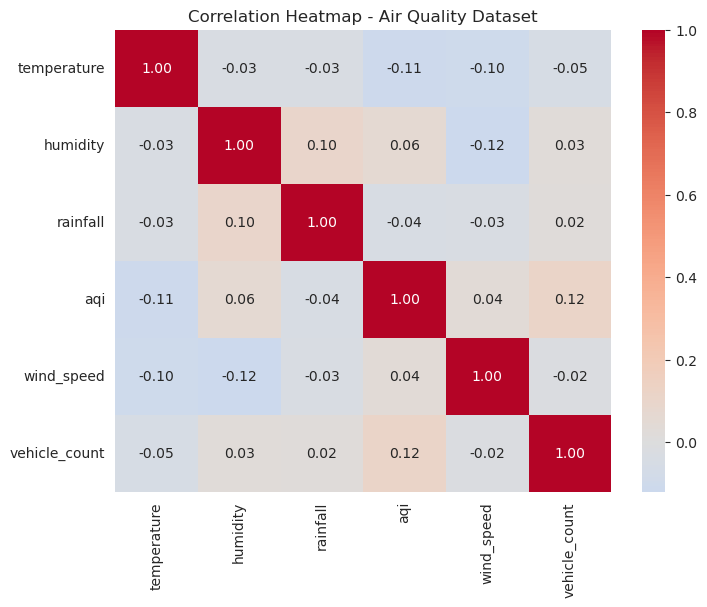

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr().round(2),annot=True,cmap="coolwarm",center=0,fmt=".2f")
plt.title("Correlation Heatmap - Air Quality Dataset")
plt.show()

**Solution:** the strongest absolute correlation is between wind_speed and vehicle_count at 0.28,
a weak positive relationship. this pair was not one of the three plotted in Task 14, but it is stronger
than any of those three, which fits since none of the Task 14 scatter plots showed a visible trend
while this pair at least shows a mild upward drift.

## B.6 Take-Home

**Task 17:** df_dropped versus df_imputed comparison

dropped shape: (101, 6)
imputed shape: (200, 6)


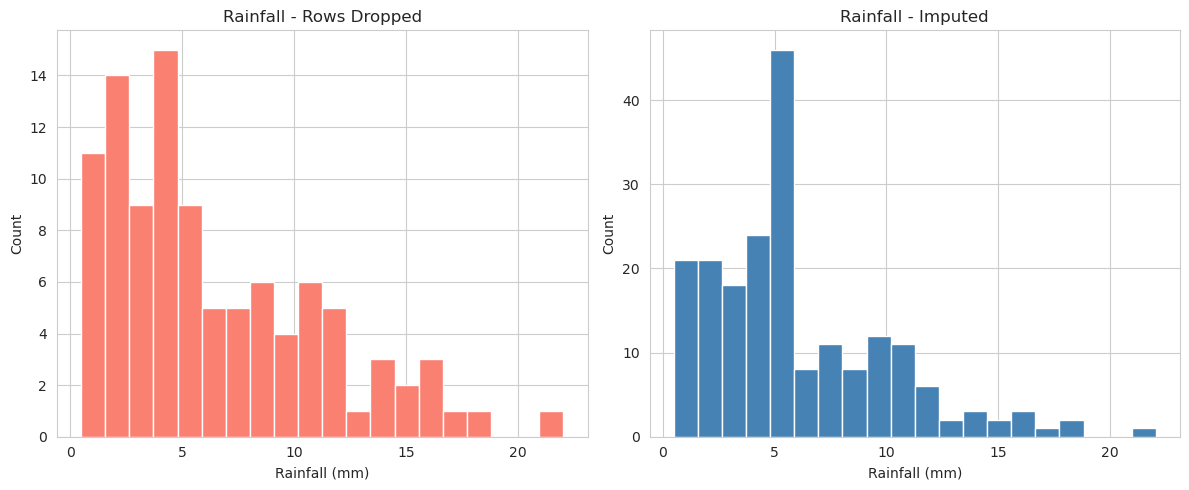

In [26]:
df_dropped=df.dropna()
df_imputed=df_clean.copy()
print("dropped shape:",df_dropped.shape)
print("imputed shape:",df_imputed.shape)
fig,ax=plt.subplots(1,2,figsize=(12,5))
ax[0].hist(df_dropped["rainfall"],bins=20,color="salmon")
ax[0].set_title("Rainfall - Rows Dropped")
ax[0].set_xlabel("Rainfall (mm)")
ax[0].set_ylabel("Count")
ax[1].hist(df_imputed["rainfall"],bins=20,color="steelblue")
ax[1].set_title("Rainfall - Imputed")
ax[1].set_xlabel("Rainfall (mm)")
ax[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

**Solution:** dropping every row with any missing value shrinks the dataset from 200 to 118 rows,
a loss of 82 rows or 41% of the data, just from six columns each missing a small fraction independently.
the overall rainfall shape stays right-skewed in both versions, but the dropped-rows histogram is
noisier with fewer bars to work with, and its mean (5.22 mm) sits a little lower than the imputed
version's mean (5.57 mm), showing that dropping rows does not just shrink the sample, it can quietly
shift the summary statistics too.

**Task 18:** additional visualisation of choice

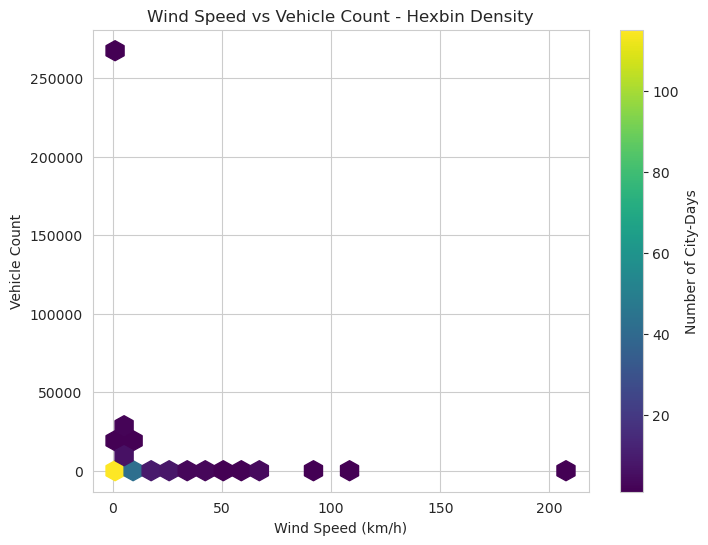

In [27]:
plt.figure(figsize=(8,6))
plt.hexbin(df_clean["wind_speed"],df_clean["vehicle_count"],gridsize=25,cmap="viridis",mincnt=1)
plt.colorbar(label="Number of City-Days")
plt.title("Wind Speed vs Vehicle Count - Hexbin Density")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("Vehicle Count")
plt.show()

**Solution:** the hexbin plot shows where city-days are densely packed for the pair with the
highest correlation found in Task 16, wind_speed and vehicle_count, with most days sitting in a small
dense patch near the low end of both axes and only a scattering of hexagons out toward the heavy tails.
a plain scatter plot of these two heavy-tailed columns would bunch almost every point on top of another
near the origin, so a hexbin was chosen instead since it colours by density and makes that concentration
readable instead of a solid blob of overlapping dots.